# Winding numbers and Z2 invariants in one dimension
In one dimension `h.get_topological_invariant()` returns the Berry (Zak) phase, which is $0$ or
$\pi$ and so only tells whether the number of zero modes at each end is even or odd. We will now see
how to count them, with `h.get_winding_number()`. When the Hamiltonian anticommutes with a chiral
operator $S$, in the eigenbasis of $S$ the Bloch Hamiltonian is off-diagonal, with a block $q(k)$,
and the winding number

$$
W = \frac{1}{2\pi i}\oint dk\, \partial_k \log\det q(k)
$$

counts how many times the phase of $\det q(k)$ goes around as $k$ crosses the Brillouin zone,
which is the number of zero modes at each end of an open chain. For a normal Hamiltonian $S$ is
the sublattice operator, and for a Nambu Hamiltonian it is $\sigma_y\tau_y$, so the same call
counts the Majorana zero modes of Kitaev chains. A time-reversal-symmetric superconducting wire, a
class DIII superconductor, has instead a Kramers pair of Majorana zero modes at each end, which
neither the Zak phase nor the winding sees; for it `h.get_topological_invariant()` returns the
$Z_2$ Kramers polarization $\nu = \det U \, \mathrm{Pf}\,\theta(0)/\mathrm{Pf}\,\theta(\pi)$,
which compares how the Kramers partners are paired at the two ends of half of the Brillouin zone.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology


### Two coupled Kitaev chains: the winding counts, the Zak phase does not
We couple two Kitaev chains by a rung hopping $t_\perp$, which splits their bands by $\pm t_\perp$,
and map the winding number and the Zak phase over the chemical potential and $t_\perp$. The winding
is the number of chains whose band contains the Fermi energy, $0$, $1$ or $2$, while the Zak phase
is $\pi$ only where the winding is odd: in the region with two Majorana zero modes at each end it
reads $0$, the same as a trivial ladder. Where the gap closes the winding is not defined and the map
is left blank.

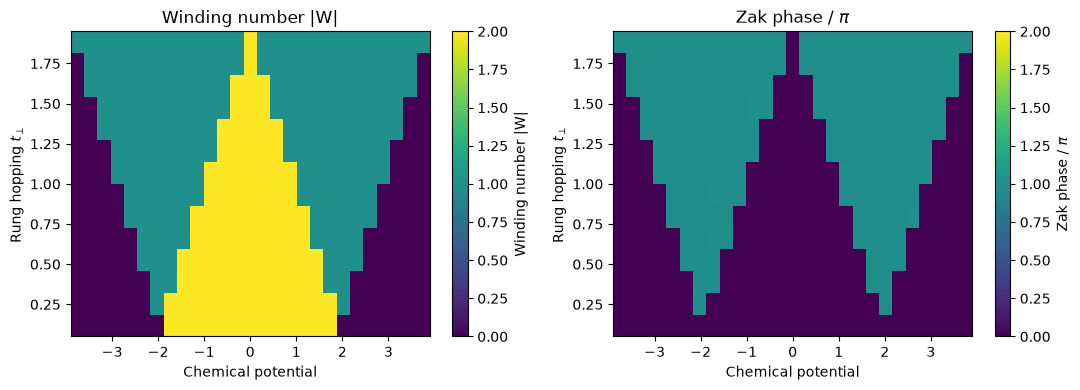

In [2]:
def xpwave(r1,r2): # p-wave pairing on the bonds along x only
    dr = r1-r2
    if abs(np.linalg.norm(dr)-1.)<1e-4 and abs(dr[1])<1e-6:
        return dr[0]*np.array([[0.,1.],[1.,0.]],dtype=complex)
    return np.zeros((2,2),dtype=complex)

def kitaev_ladder(mu,tperp):
    def fun(r1,r2): # hopping 1 along the chains, tperp on the rungs
        dr = r1-r2
        if abs(np.linalg.norm(dr)-1.)>1e-4: return 0.
        return 1. if abs(dr[1])<1e-6 else tperp
    h = geometry.ladder().get_hamiltonian(fun=fun) # two coupled chains
    h.add_onsite(20.+mu) # shift both spin bands up
    h.add_zeeman([0.,0.,20.]) # and bring one of them back to the Fermi energy
    h.add_pairing(mode=xpwave,delta=0.3) # p-wave pairing: two Kitaev chains
    return h

mus = np.linspace(-3.9,3.9,27) # chemical potential
tps = np.linspace(0.05,1.95,14) # rung hopping
W = np.zeros((len(tps),len(mus))) ; Z = np.zeros((len(tps),len(mus)))
for (i,tp) in enumerate(tps):
    for (j,mu) in enumerate(mus):
        h = kitaev_ladder(mu,tp)
        try:
            W[i,j] = h.get_winding_number() # winding number
            Z[i,j] = abs(topology.berry_phase(h,nk=100,write=False))/np.pi # Zak phase/pi
        except Exception: W[i,j] = Z[i,j] = np.nan # gap closing

fig,axs = plt.subplots(1,2,figsize=(11,4))
ext = [mus[0],mus[-1],tps[0],tps[-1]]
for (ax,M,name) in [(axs[0],np.abs(W),"Winding number |W|"),(axs[1],Z,"Zak phase / $\\pi$")]:
    im = ax.imshow(M,origin="lower",aspect="auto",extent=ext,cmap="viridis",vmin=0,vmax=2)
    fig.colorbar(im,ax=ax,label=name)
    ax.set_xlabel("Chemical potential") ; ax.set_ylabel("Rung hopping $t_\\perp$")
    ax.set_title(name)
plt.tight_layout()
plt.show()


### Phase diagram of a helical superconducting wire
We now take a helical p-wave wire, where the two spins pair with opposite chirality, with a Rashba
coupling so that spin is not conserved, and a competing s-wave pairing, and map the $Z_2$ invariant
over the chemical potential and the s-wave pairing. The wire is topological, $\nu=-1$, while the
Fermi energy is inside the band and the p-wave pairing dominates; a strong enough s-wave pairing
closes the gap and makes it trivial, $\nu=+1$, and so does emptying or filling the band.

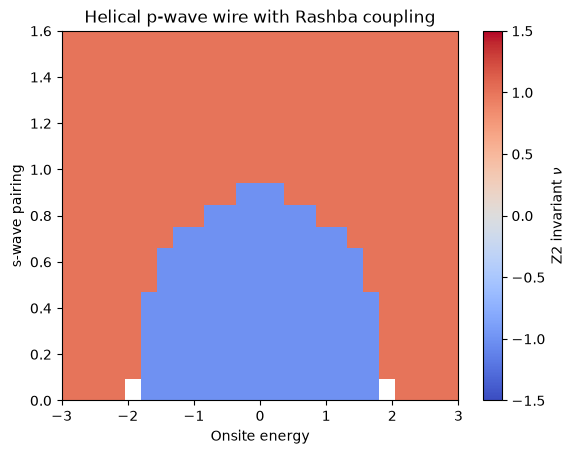

In [3]:
mus = np.linspace(-3.,3.,25) # onsite energy, the chemical potential with opposite sign
dss = np.linspace(0.,1.6,17) # s-wave pairing
NU = np.zeros((len(dss),len(mus)))
for (i,ds) in enumerate(dss):
    for (j,mu) in enumerate(mus):
        h = geometry.chain().get_hamiltonian() # spinful chain
        h.add_onsite(mu) # shift the band
        h.add_rashba(0.2) # Rashba spin-orbit coupling, so that spin is not conserved
        h.add_pairing(mode="pwave",delta=0.5j,d=[1.,0.,0.]) # helical p-wave pairing
        if ds>0.: h.add_swave(ds) # competing s-wave pairing
        try: NU[i,j] = h.get_topological_invariant() # Z2 invariant of the wire
        except Exception: NU[i,j] = np.nan # gap closing

plt.imshow(NU,origin="lower",aspect="auto",cmap="coolwarm",vmin=-1.5,vmax=1.5,
           extent=[mus[0],mus[-1],dss[0],dss[-1]])
plt.colorbar(label="Z2 invariant $\\nu$")
plt.xlabel("Onsite energy") ; plt.ylabel("s-wave pairing")
plt.title("Helical p-wave wire with Rashba coupling")
plt.show()
